# 👑 Analisis Graf: Silsilah Kerajaan Nusantara
**Mata Kuliah Graf - Departemen Sistem Informasi ITS**

Notebook ini digunakan untuk membangun graf silsilah kekerabatan dan menjalankan 3 algoritma utama:
1. **Degree Centrality** (Mencari tokoh paling sentral/berpengaruh)
2. **Community Detection** (Mencari klaster wangsa/dinasti alami)
3. **Jaccard Similarity** (Mencari kemiripan antar tokoh)

In [28]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms import community

# Load data asli dari folder data
file_path = '../data/dataset_gabungan_uts_graf.csv'
df = pd.read_csv(file_path)

print("✅ Data berhasil masuk, siap dimasak!")
display(df.head())

✅ Data berhasil masuk, siap dimasak!


,kerajaan,orang,peran,ayah,ibu,pasangan,anak,namaKerajaan,ibuKota,agama,pendahulu,penerus,tahunMulai,wikidataID
0,Kesultanan Banjar,Soeria Kasoema,pejabat pemerintahan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Kerajaan Klungkung,Dewa Agung Jambe I,NaN,NaN,NaN,NaN,Dewa Agung Gede,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Kerajaan Klungkung,Dewa Agung Jambe II,NaN,Dewa Agung Putra III Bhatara Dalem,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Kerajaan Klungkung,Dewa Agung Putra I Kusamba,NaN,Dewa Agung Ã…Å¡akti,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Kerajaan Klungkung,Dewa Agung Putra III Bhatara Dalem,NaN,NaN,NaN,NaN,Dewa Agung Jambe II,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
# Inisialisasi Graf Kosong
G = nx.Graph()

for index, row in df.iterrows():
    # Entitas Utama (Kolom B)
    tokoh = str(row['orang']) 
    
    # Ambil data relasi (Kolom D - L)
    ayah = str(row['ayah'])
    ibu = str(row['ibu'])
    pasangan = str(row['pasangan'])
    anak = str(row['anak'])
    pendahulu = str(row['pendahulu'])
    penerus = str(row['penerus'])
    
    # 1. TAMBAH NODE + ATRIBUT (Pake .get() biar aman sentosa)
    G.add_node(tokoh, 
               kerajaan=row.get('namaKerajaan', ''), 
               peran=row.get('peran', ''),
               agama=row.get('agama', ''),
               ibu_kota=row.get('ibuKota', ''),
               tahun_mulai=row.get('tahunMulai', ''),
               wiki_id=row.get('wikidataID', ''))
    
    # 2. JAHIT RELASI KELUARGA
    if ayah and ayah != 'nan':
        G.add_edge(ayah, tokoh, relasi="AYAH_DARI")
    if ibu and ibu != 'nan':
        G.add_edge(ibu, tokoh, relasi="IBU_DARI")
    if pasangan and pasangan != 'nan':
        G.add_edge(tokoh, pasangan, relasi="MENIKAH_DENGAN")
    if anak and anak != 'nan':
        G.add_edge(tokoh, anak, relasi="ORANGTUA_DARI")
        
    # 3. JAHIT RELASI SUKSESI
    if pendahulu and pendahulu != 'nan':
        G.add_edge(pendahulu, tokoh, relasi="DITERUSKAN_OLEH")
    if penerus and penerus != 'nan':
        G.add_edge(tokoh, penerus, relasi="DITERUSKAN_OLEH")

print(f"🕸️ GRAF FINAL TERBENTUK: {G.number_of_nodes()} Nodes & {G.number_of_edges()} Edges.")

🕸️ GRAF FINAL TERBENTUK: 179 Nodes & 191 Edges.


In [30]:
import networkx.algorithms.community as nx_comm

print("🔥 HASIL ANALISIS ALGORITMA GRAF (SESUAI RUBRIK DOSEN) 🔥\n")

# ==========================================
# 1. CENTRALITY: PAGERANK
# ==========================================
print("1️⃣ TOKOH PALING PENTING (Algoritma: PageRank Centrality)")
print("📝 Penjelasan: Menemukan entitas paling berpengaruh berdasarkan aliran relasi (kekuasaan/kekerabatan).")
# Hitung PageRank
pagerank_scores = nx.pagerank(G)
# Urutkan dari yang paling tinggi
sorted_pr = sorted(pagerank_scores.items(), key=lambda item: item[1], reverse=True)
# Tampilkan Top 5
for t, skor in sorted_pr[:5]:
    print(f"   👑 {t}: {skor:.4f}")


# ==========================================
# 2. COMMUNITY DETECTION: LOUVAIN
# ==========================================
print("\n2️⃣ DETEKSI PENGELOMPOKAN ALAMI (Algoritma: Louvain Community)")
print("📝 Penjelasan: Mempartisi graf ke dalam klaster Wangsa/Dinasti alami secara otomatis.")
# Hitung Louvain Communities
louvain_comms = list(nx_comm.louvain_communities(G))
# Urutkan klaster dari yang paling banyak anggotanya ke yang paling dikit
louvain_comms = sorted(louvain_comms, key=len, reverse=True)
# Tampilkan Klasternya
for i, sirkel in enumerate(louvain_comms):
    # Kita filter, cuma tampilin klaster yang isinya lebih dari 1 orang 
    # (biar 'nan' dan 'orangLabel' yang jomblo ngga terlalu menuhin layar wkwk)
    if len(sirkel) > 1:
        print(f"   🏰 Klaster {i+1} ({len(sirkel)} Tokoh): {list(sirkel)}")


# ==========================================
# 3. SIMILARITY: JACCARD
# ==========================================
print("\n3️⃣ KEMIRIPAN ANTAR ENTITAS (Algoritma: Jaccard Similarity)")
print("📝 Penjelasan: Mengukur kemiripan dua tokoh berdasarkan irisan atribut/relasi tetangganya.")
# Hitung Jaccard Coefficient
jaccard_scores = nx.jaccard_coefficient(G)
# Urutkan dari yang paling mirip (Skor mendekati 1.0)
sorted_jaccard = sorted(jaccard_scores, key=lambda x: x[2], reverse=True)
# Tampilkan Top 5 Pasangan Termirip
for u, v, p in sorted_jaccard[:5]:
    if p > 0:
        print(f"   🪞 {u} & {v} (Skor Kemiripan: {p:.2f})")

🔥 HASIL ANALISIS ALGORITMA GRAF (SESUAI RUBRIK DOSEN) 🔥

1️⃣ TOKOH PALING PENTING (Algoritma: PageRank Centrality)
📝 Penjelasan: Menemukan entitas paling berpengaruh berdasarkan aliran relasi (kekuasaan/kekerabatan).
   👑 Kertabhumi: 0.0178
   👑 Singhasari: 0.0148
   👑 Demak Sultanate: 0.0148
   👑 Pagaruyung Kingdom: 0.0148
   👑 Blambangan Kingdom: 0.0148

2️⃣ DETEKSI PENGELOMPOKAN ALAMI (Algoritma: Louvain Community)
📝 Penjelasan: Mempartisi graf ke dalam klaster Wangsa/Dinasti alami secara otomatis.
   🏰 Klaster 1 (25 Tokoh): ['Dyah Nertaja', 'Singhasari', 'Taming Sari', 'Bruneian Sultanate', 'Mpu Kuturan', 'Suhita', 'Blambangan Kingdom', 'Kusumawardhani', 'Raden Hamzah', 'Sunan Bayat', 'Kertawijaya', 'Sunan Mertayasa', 'Suraprabhawa', 'Sultanate of Gowa', 'Malacca Sultanate', 'Sunan Bungkul', 'Ra Kuti', 'Demak Sultanate', 'Maulana Ishaq', 'Pagaruyung Kingdom', 'Sunan Demak', 'Wikramawardhana', 'Patih Udara', 'Mpu Tantular', 'Gajah Mada']
   🏰 Klaster 2 (17 Tokoh): ['Abu al-Fadhl', '

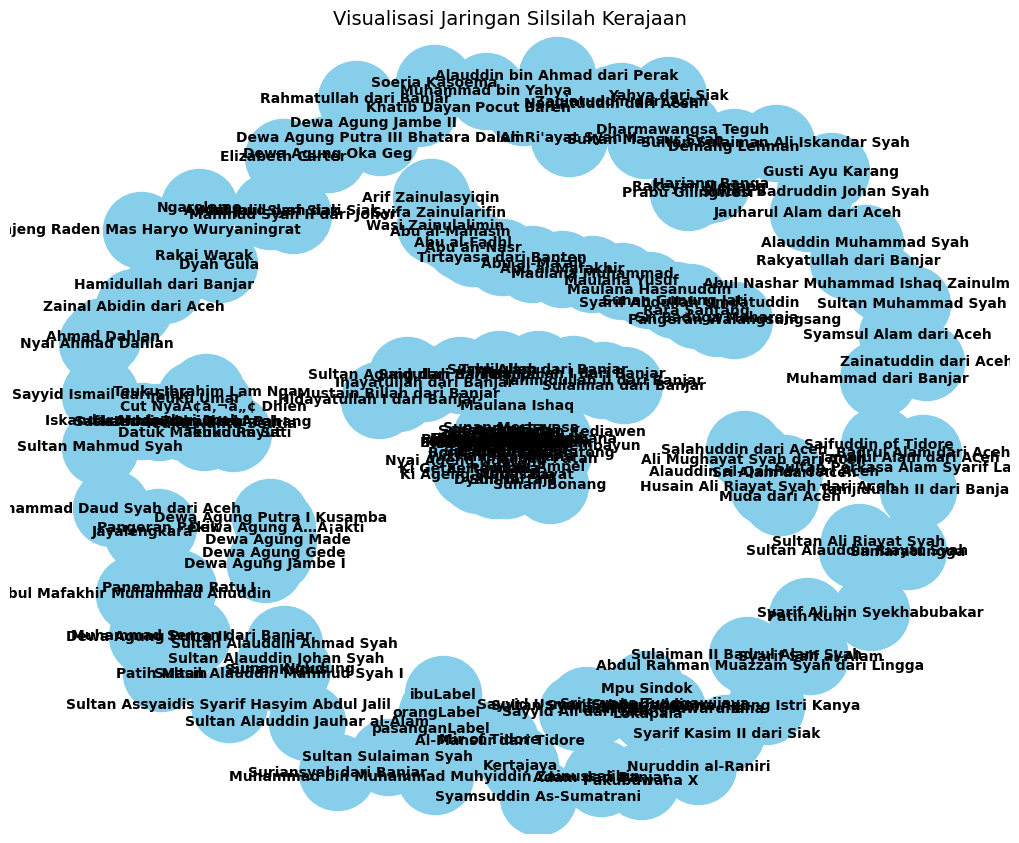

In [31]:
plt.figure(figsize=(10, 8))

# Atur posisi layout biar estetik
pos = nx.spring_layout(G, seed=42)

# Gambar Node dan Label
nx.draw(G, pos, with_labels=True, node_color='skyblue', 
        node_size=3000, font_size=10, font_weight='bold', 
        edge_color='gray', width=2)

plt.title("Visualisasi Jaringan Silsilah Kerajaan", fontsize=14)
plt.show()